In [146]:
import numpy
import SimFunctions
import SimRNG
import SimClasses
import sys

# Initialize simulation variables
ZRNG = SimRNG.InitializeRNSeed()
Calendar = SimClasses.EventCalendar()

# Simulation Parameters
# תוחלת זמני שהייה  בשעות בחדר מיון הכללי
acuteED_mean = 10
notacuteED_mean = 12
complexED_mean = 15
complexED_CT_mean = 16

#משכי השגחה וטיפול במחלקת תמיכה - שחרור
acuteSR_time = 6
notacuteSR_time = 3
complexSR_time = 5
easySR_mean = 3

# Arrival rates
acuteFlow = [240, 270, 300, 240, 300, 360, 360, 300, 270, 300, 360, 600, 690, 780, 900, 900, 870, 240, 270, 300, 300, 240, 240, 240]
notAcuteFlow = [600, 600, 690, 900, 960, 870, 900, 930, 1200, 1500, 2100, 2070, 2040, 1950, 2100, 1200, 1200, 1140, 1170, 930, 600, 750, 600, 600]
complexFlow = [300, 300, 270, 240, 240, 240, 270, 300, 330, 360, 330, 450, 480, 510, 540, 570, 570, 420, 330, 330, 300, 330, 420, 360]
easyFlow = [900, 900, 990, 990, 960, 990, 1080, 1140, 1200, 1350, 1800, 1860, 1950, 1980, 2070, 2100, 2400, 2160, 1500, 1470, 1350, 1290, 1110, 900]


total_rate = [a + b + c + d for a, b, c, d in zip(acuteFlow, notAcuteFlow, complexFlow, easyFlow)]

# הסתברויות חזרה למחלקת המיון אחרי סיום השגחה
complexCT_PROB = 0.7
acute_backPROB = 0.43
notacute_backPROB = 0.4
complex_backPROB = 0.7

# Resource parameters
numBedsED = 35
numBedsSR = 20

# Simulation parameters
NumReps = 5000
run_length = 1344

class TimeWeightedStat:
    def __init__(self):
        self.last_time = 0
        self.last_value = 0
        self.weighted_sum = 0
        self.total_time = 0
        self.max_value = 0

    def record(self, current_time, value):
        """מוודא שהערך לא עובר 1.0"""
        time_diff = current_time - self.last_time
        self.weighted_sum += self.last_value * time_diff
        self.total_time += time_diff
        self.last_time = current_time
        self.last_value = min(value, 1.0)  # מגביל את הערך ל-1.0
        self.max_value = max(self.max_value, self.last_value)

    def Mean(self):
        if self.total_time == 0:
            return 0
        return min(self.weighted_sum / self.total_time, 100.0)  # מוודא שהממוצע לא עובר 1.0
# Resources and Statistics
ED_beds = SimClasses.Resource()
ED_beds.SetUnits(numBedsED)
SR_beds = SimClasses.Resource()
SR_beds.SetUnits(numBedsSR)

ED_Queue = SimClasses.FIFOQueue()
SR_Queue = SimClasses.FIFOQueue()

# Statistics
acute_stat = SimClasses.DTStat()
notacute_stat = SimClasses.DTStat()
complex_stat = SimClasses.DTStat()
easy_stat = SimClasses.DTStat()

# Time-weighted utilization statistics
ED_utilization = TimeWeightedStat()
SR_utilization = TimeWeightedStat()

# Patient tracking
patient_arrival_times = {}
patient_type_tracker = {}

# RNG Seeds
arrival = 1
leave = 2

#פונקציית דגימת הגעות בתהליך פואסון לא הומוגני בזמן
def NSPP(Stream):
    PossibleArrivalTime = SimClasses.Clock
    Ratio = 0
    while SimRNG.Uniform(0, 1, Stream) >= Ratio:
        hour_index = int(SimClasses.Clock) % len(total_rate)
        PossibleArrivalTime += SimRNG.Expon(1 / total_rate[hour_index], Stream)
        Ratio = total_rate[hour_index] / max(total_rate)
    return PossibleArrivalTime - SimClasses.Clock

#פונקצייה שמחזירה את המטופל הבא ומתי הוא הגיע
def get_next_patient_type():
    arrival_times = {
        "Acute": NSPP(arrival),
        "NotAcute": NSPP(arrival),
        "Complex": NSPP(arrival),
        "Easy": NSPP(arrival),
    }
    next_type = min(arrival_times, key=arrival_times.get)
    return next_type, arrival_times[next_type]

def Arrival(patient_type):
    if patient_type is None:
        return

    patient_id = f"{patient_type}_{len(patient_arrival_times)}"
    patient_arrival_times[patient_id] = SimClasses.Clock
    patient_type_tracker[patient_id] = patient_type

    if patient_type == "Acute":
        if ED_beds.CurrentNumBusy < numBedsED:
            ED_beds.Seize(1)
            ED_utilization.record(SimClasses.Clock, ED_beds.CurrentNumBusy / numBedsED)
            SimFunctions.SchedulePlus(Calendar, "ED_Complete", SimRNG.Expon(acuteED_mean, leave), [patient_id, patient_type])
        else:
            ED_Queue.Add([patient_id, patient_type])
    elif patient_type == "NotAcute":
        if ED_beds.CurrentNumBusy < numBedsED:
            ED_beds.Seize(1)
            ED_utilization.record(SimClasses.Clock, ED_beds.CurrentNumBusy / numBedsED)
            SimFunctions.SchedulePlus(Calendar, "ED_Complete", SimRNG.Expon(notacuteED_mean, leave), [patient_id, patient_type])
        else:
            ED_Queue.Add([patient_id, patient_type])
    elif patient_type == "Complex":
        if ED_beds.CurrentNumBusy < numBedsED:
            ED_beds.Seize(1)
            ED_utilization.record(SimClasses.Clock, ED_beds.CurrentNumBusy / numBedsED)
            if SimRNG.Uniform(0, 1, leave) < complexCT_PROB:
                SimFunctions.SchedulePlus(Calendar, "CT_Complete", SimRNG.Expon(complexED_CT_mean, leave), [patient_id, patient_type])
            else:
                SimFunctions.SchedulePlus(Calendar, "ED_Complete", SimRNG.Expon(complexED_mean, leave), [patient_id, patient_type])
        else:
            ED_Queue.Add([patient_id, patient_type])
    elif patient_type == "Easy":
        if SR_beds.CurrentNumBusy < numBedsSR:
            SR_beds.Seize(1)
            SR_utilization.record(SimClasses.Clock, SR_beds.CurrentNumBusy / numBedsSR)
            SimFunctions.SchedulePlus(Calendar, "SR_Complete_Easy", SimRNG.Expon(easySR_mean, leave), [patient_id, patient_type])
        else:
            SR_Queue.Add([patient_id, patient_type])

    next_patient_type, next_arrival_time = get_next_patient_type()
    SimFunctions.SchedulePlus(Calendar, "Arrival", SimClasses.Clock + next_arrival_time, [next_patient_type])


#סיום טיפול במיון ומעבר למחלקת תמיכה - שחרור
def ED_Complete(event_data):
    if not event_data or len(event_data) < 2:
        return

    patient_id, patient_type = event_data
    arrival_time = patient_arrival_times.get(patient_id, SimClasses.Clock)
    wait_time = SimClasses.Clock - arrival_time

    if patient_type == "Acute":
        acute_stat.Record(wait_time)
        if SR_beds.CurrentNumBusy < numBedsSR:
            SR_beds.Seize(1)
            SR_utilization.record(SimClasses.Clock, SR_beds.CurrentNumBusy / numBedsSR)
            SimFunctions.SchedulePlus(Calendar, "SR_Complete_Acute", acuteSR_time, [patient_id, patient_type])
    elif patient_type == "NotAcute":
        notacute_stat.Record(wait_time)
        if SR_beds.CurrentNumBusy < numBedsSR:
            SR_beds.Seize(1)
            SR_utilization.record(SimClasses.Clock, SR_beds.CurrentNumBusy / numBedsSR)
            SimFunctions.SchedulePlus(Calendar, "SR_Complete_NotAcute", notacuteSR_time, [patient_id, patient_type])
    elif patient_type == "Complex":
        complex_stat.Record(wait_time)
        if SR_beds.CurrentNumBusy < numBedsSR:
            SR_beds.Seize(1)
            SR_utilization.record(SimClasses.Clock, SR_beds.CurrentNumBusy / numBedsSR)
            SimFunctions.SchedulePlus(Calendar, "SR_Complete_Complex", complexSR_time, [patient_id, patient_type])

    ED_beds.Free(1)
    ED_utilization.record(SimClasses.Clock, ED_beds.CurrentNumBusy / numBedsED)

    if ED_Queue.NumQueue() > 0:
        next_patient = ED_Queue.Remove()
        SimFunctions.SchedulePlus(Calendar, "Arrival", 0, [next_patient[0], next_patient[1]])

def CT_Complete(event_data):
    patient_id, patient_type = event_data
    
    ED_beds.Free(1)
    ED_utilization.record(SimClasses.Clock, ED_beds.CurrentNumBusy / numBedsED)

    if ED_Queue.NumQueue() > 0:
        next_patient = ED_Queue.Remove()
        SimFunctions.SchedulePlus(Calendar, "Arrival", 0, [next_patient[0], next_patient[1]])



def SR_Complete_Easy(event_data):
    patient_id, patient_type = event_data
    easy_stat.Record(SimClasses.Clock - patient_arrival_times.get(patient_id, SimClasses.Clock))
    
    SR_beds.Free(1)
    SR_utilization.record(SimClasses.Clock, SR_beds.CurrentNumBusy / numBedsSR)

    if SR_Queue.NumQueue() > 0:
        next_patient = SR_Queue.Remove()
        SimFunctions.SchedulePlus(Calendar, "Arrival", 0, [next_patient[0], next_patient[1]])


#פונקציות סיום השגחה במחלקת תמיכה - שחרור עם סיכוי למעבר חזרה למיון
def SR_Complete_Acute(event_data):
    patient_id, patient_type = event_data
    if SimRNG.Uniform(0, 1, leave) < acute_backPROB:
        SimFunctions.SchedulePlus(Calendar, "Arrival", 0, [patient_id, patient_type])

    SR_beds.Free(1)
    SR_utilization.record(SimClasses.Clock, SR_beds.CurrentNumBusy / numBedsSR)

    if SR_Queue.NumQueue() > 0:
        next_patient = SR_Queue.Remove()
        SimFunctions.SchedulePlus(Calendar, "Arrival", 0, [next_patient[0], next_patient[1]])

def SR_Complete_NotAcute(event_data):
    patient_id, patient_type = event_data
    if SimRNG.Uniform(0, 1, leave) < notacute_backPROB:
        SimFunctions.SchedulePlus(Calendar, "Arrival", 0, [patient_id, patient_type])
    
    SR_beds.Free(1)
    SR_utilization.record(SimClasses.Clock, SR_beds.CurrentNumBusy / numBedsSR)

    if SR_Queue.NumQueue() > 0:
        next_patient = SR_Queue.Remove()
        SimFunctions.SchedulePlus(Calendar, "Arrival", 0, [next_patient[0], next_patient[1]])

def SR_Complete_Complex(event_data):
    patient_id, patient_type = event_data
    if SimRNG.Uniform(0, 1, leave) < complex_backPROB:
        SimFunctions.SchedulePlus(Calendar, "Arrival", 0, [patient_id, patient_type])
    
    SR_beds.Free(1)
    SR_utilization.record(SimClasses.Clock, SR_beds.CurrentNumBusy / numBedsSR)

    if SR_Queue.NumQueue() > 0:
        next_patient = SR_Queue.Remove()
        SimFunctions.SchedulePlus(Calendar, "Arrival", 0, [next_patient[0], next_patient[1]])

# Main Simulation Loop
for rep in range(NumReps):
    SimFunctions.SimFunctionsInit(Calendar)
    next_patient_type, next_arrival_time = get_next_patient_type()
    SimFunctions.SchedulePlus(Calendar, "Arrival", SimClasses.Clock + next_arrival_time, [next_patient_type])
    SimFunctions.Schedule(Calendar, "EndOfSimulation", run_length)

    while Calendar.N() > 0:
        NextEvent = Calendar.Remove()
        SimClasses.Clock = NextEvent.EventTime
        if NextEvent.EventType == "Arrival":
            Arrival(NextEvent.WhichObject[0])
        elif NextEvent.EventType == "ED_Complete":
            ED_Complete(NextEvent.WhichObject)
        elif NextEvent.EventType == "CT_Complete":
            CT_Complete(NextEvent.WhichObject)
        elif NextEvent.EventType == "SR_Complete_Easy":
            SR_Complete_Easy(NextEvent.WhichObject)
        elif NextEvent.EventType == "SR_Complete_Acute":
            SR_Complete_Acute(NextEvent.WhichObject)
        elif NextEvent.EventType == "SR_Complete_NotAcute":
            SR_Complete_NotAcute(NextEvent.WhichObject)
        elif NextEvent.EventType == "SR_Complete_Complex":
            SR_Complete_Complex(NextEvent.WhichObject)
        elif NextEvent.EventType == "EndOfSimulation":
            break

# Final Statistics
print(f"Avg time in ED for Acute: {acute_stat.Mean():.2f}")
print(f"Avg time in ED for NotAcute: {notacute_stat.Mean():.2f}")
print(f"Avg time in ED for Complex: {complex_stat.Mean():.2f}")
print(f"Avg time for Easy Cases: {easy_stat.Mean():.2f}")
print(f"ED Beds utilization: {ED_utilization.Mean():.2f}")
print(f"SR Beds utilization: {SR_utilization.Mean():.2f}")

Avg time in ED for Acute: 11.83
Avg time in ED for NotAcute: 14.76
Avg time in ED for Complex: 22.99
Avg time for Easy Cases: 2.76
ED Beds utilization: 39.72
SR Beds utilization: 100.00


                                                        Output Analysis

In [147]:
import os
os.makedirs("/data/workspace_files/OutputAnalysis_outputs", exist_ok=True)

Outputs

In [148]:
import pandas as pd
import numpy as np
import scipy.stats as scs

# יצירת מילון לאיסוף התוצאות
simulation_results = {
    "numBedsED": numBedsED,
    "numBedsSR": numBedsSR,
    "Avg_Acute_ED_Time": acute_stat.Mean(),
    "Avg_NotAcute_ED_Time": notacute_stat.Mean(),
    "Avg_Complex_ED_Time": complex_stat.Mean(),
    "Avg_Easy_SR_Time": easy_stat.Mean(),
    "ED_Utilization": ED_utilization.Mean(),
    "SR_Utilization": SR_utilization.Mean()
   
}

# יצירת תיקיית שמירה במידת הצורך
output_folder = "simulation_results"
os.makedirs(output_folder, exist_ok=True)

# שם הקובץ לפי מספר המיטות
file_name = f"results_ED_{numBedsED}_SR_{numBedsSR}.csv"
file_path = os.path.join(output_folder, file_name)

# המרת הנתונים ל-DataFrame ושמירה לקובץ
df_results = pd.DataFrame([simulation_results])
df_results.to_csv(file_path, index=False)

print(f"Results saved to {file_path}")

Results saved to simulation_results/results_ED_50_SR_5.csv


In [149]:

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns; sns.set()

In [150]:
# הגדרת תיקיית השמירה עבור תוצאות הסימולציה
results_folder = "simulation_results"

# יצירת רשימה של נתיבי הקבצים בתיקייה
results_paths = [os.path.join(results_folder, result) for result in os.listdir(results_folder)]

# הדפסת רשימת הנתיבים
print(results_paths)

['simulation_results/results_ED_45_SR_10.csv', 'simulation_results/results_ED_40_SR_15.csv', 'simulation_results/results_ED_50_SR_5.csv', 'simulation_results/results_ED_30_SR_25.csv', 'simulation_results/results_ED_35_SR_20.csv']


In [151]:
# יצירת מילון שמכיל את הדאטה פריימים של כל קובץ בתיקייה
results_dfs = {os.path.splitext(os.path.basename(path))[0]: pd.read_csv(os.path.join(results_folder, path), index_col=0) 
               for path in os.listdir(results_folder)}

# בחירת קובץ בסיס (לדוגמה, אם שם הקובץ תואם למספר מיטות מסוים)
baseline = results_dfs.get("results_ED_50_SR_5", None)

# קבלת שמות העמודות למטריקות
if baseline is not None:
    metrics = baseline.columns
else:
    print("Baseline file not found!")

# הדפסת שמות הקבצים עם הנתונים כבדיקה
print(results_dfs.keys())

dict_keys(['results_ED_45_SR_10', 'results_ED_40_SR_15', 'results_ED_50_SR_5', 'results_ED_30_SR_25', 'results_ED_35_SR_20'])


In [152]:
results_dfs

{'results_ED_45_SR_10':            numBedsSR  Avg_Acute_ED_Time  Avg_NotAcute_ED_Time  \
 numBedsED                                                       
 45                10           14.24841              9.170334   
 
            Avg_Complex_ED_Time  Avg_Easy_SR_Time  ED_Utilization  \
 numBedsED                                                          
 45                    9.175575          2.079428       36.264787   
 
            SR_Utilization  
 numBedsED                  
 45              55.762815  ,
 'results_ED_40_SR_15':            numBedsSR  Avg_Acute_ED_Time  Avg_NotAcute_ED_Time  \
 numBedsED                                                       
 40                15          10.987166             16.483732   
 
            Avg_Complex_ED_Time  Avg_Easy_SR_Time  ED_Utilization  \
 numBedsED                                                          
 40                    8.975786          2.008772       42.487239   
 
            SR_Utilization  
 numBedsED         

Outputs Analysis

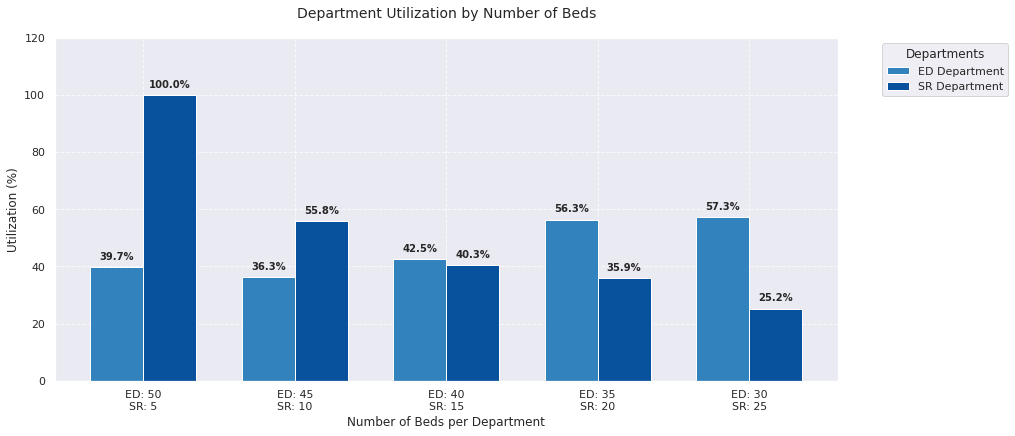

In [153]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Load results from simulation_results folder
results_folder = "simulation_results"  
results_files = [f for f in os.listdir(results_folder) if f.startswith('results_ED_') and f.endswith('.csv')]

# Create empty lists to store data
bed_combinations = []
ed_utilization = []
sr_utilization = []

# Process each results file
for file in results_files:
    df = pd.read_csv(os.path.join(results_folder, file))
    
    # Get bed configurations
    ed_beds = df['numBedsED'].iloc[0]
    sr_beds = df['numBedsSR'].iloc[0]
    bed_combinations.append(f"ED: {int(ed_beds)}\nSR: {int(sr_beds)}")
    
    # Get utilization values (already in percentages)
    ed_utilization.append(df['ED_Utilization'].iloc[0])
    sr_utilization.append(df['SR_Utilization'].iloc[0])

# Sort data by ED beds (in descending order)
sorted_indices = sorted(range(len(bed_combinations)), 
                      key=lambda k: int(bed_combinations[k].split('\n')[0].split(': ')[1]),
                      reverse=True)

bed_combinations = [bed_combinations[i] for i in sorted_indices]
ed_utilization = [ed_utilization[i] for i in sorted_indices]
sr_utilization = [sr_utilization[i] for i in sorted_indices]

# Create the plot
plt.figure(figsize=(15, 7))
x = np.arange(len(bed_combinations))
width = 0.35

# Create bars
bars1 = plt.bar(x - width/2, ed_utilization, width, label='ED Department', color='#3182bd')
bars2 = plt.bar(x + width/2, sr_utilization, width, label='SR Department', color='#08519c')

# Customize plot
plt.ylabel('Utilization (%)', fontsize=12)
plt.xlabel('Number of Beds per Department', fontsize=12)
plt.title('Department Utilization by Number of Beds', fontsize=14, pad=20)
plt.xticks(x, bed_combinations, rotation=0)

# Add legend
plt.legend(title='Departments', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add grid
plt.grid(True, linestyle='--', alpha=0.7)

# Set y-axis limits
plt.ylim(0, 120)  # מוגדל כדי שיהיה מרווח מעל כל הנתונים

# Add percentage labels above bars
def autolabel(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 2,  # הזזה של 2 למעלה
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(bars1)
autolabel(bars2)

# Adjust layout
plt.subplots_adjust(bottom=0.2, right=0.85)

plt.show()

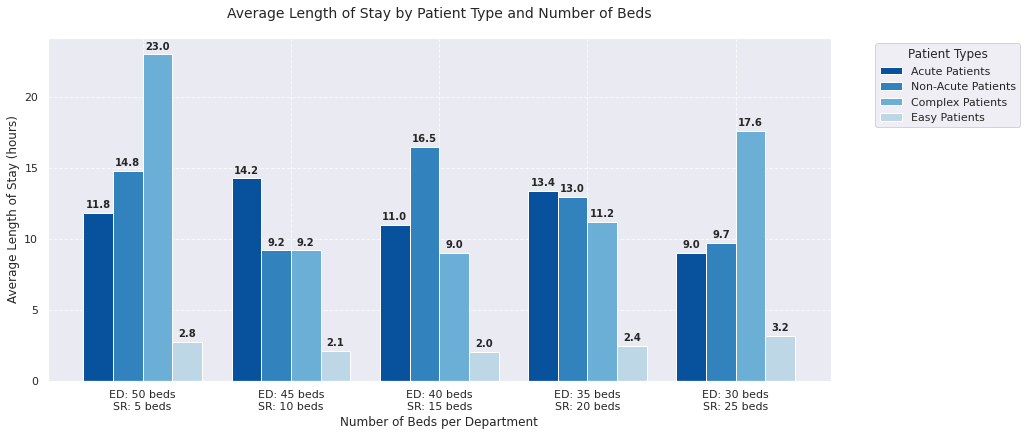

In [154]:
# Load results from saved files
results_folder = "simulation_results"
results_dfs = {os.path.splitext(os.path.basename(path))[0]: pd.read_csv(os.path.join(results_folder, path))
               for path in os.listdir(results_folder)}

# Get bed combinations from the actual data and sort them
bed_combinations = []
for filename, df in results_dfs.items():
    ed_beds = df['numBedsED'].iloc[0]  # Get the ED beds from the data
    sr_beds = df['numBedsSR'].iloc[0]  # Get the SR beds from the data
    bed_combinations.append((ed_beds, sr_beds, filename))

# Sort by ED beds in descending order
bed_combinations_sorted = sorted(bed_combinations, key=lambda x: x[0], reverse=True)

beds_combinations = []
acute_wait_avg = []
notacute_wait_avg = []
complex_wait_avg = []
easy_wait_avg = []

# Process data in sorted order
for ed_beds, sr_beds, filename in bed_combinations_sorted:
    df = results_dfs[filename]
    beds_combinations.append(f"ED: {int(ed_beds)} beds\nSR: {int(sr_beds)} beds")
    acute_wait_avg.append(df['Avg_Acute_ED_Time'].mean())
    notacute_wait_avg.append(df['Avg_NotAcute_ED_Time'].mean())
    complex_wait_avg.append(df['Avg_Complex_ED_Time'].mean())
    easy_wait_avg.append(df['Avg_Easy_SR_Time'].mean())

x = np.arange(len(beds_combinations))
width = 0.2

# הגדרת צבעים
colors = ['#08519c', '#3182bd', '#6baed6', '#bdd7e7']

fig, ax = plt.subplots(figsize=(15, 7))
bars1 = ax.bar(x - 1.5 * width, acute_wait_avg, width, label='Acute Patients', color=colors[0])
bars2 = ax.bar(x - 0.5 * width, notacute_wait_avg, width, label='Non-Acute Patients', color=colors[1])
bars3 = ax.bar(x + 0.5 * width, complex_wait_avg, width, label='Complex Patients', color=colors[2])
bars4 = ax.bar(x + 1.5 * width, easy_wait_avg, width, label='Easy Patients', color=colors[3])

# הוספת ערכים מעל כל עמודה
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}',  # הפורמט להצגת הערך
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # מרחק מהעמודה
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

# הגדרת כותרות וצירים
ax.set_ylabel('Average Length of Stay (hours)', fontsize=12)
ax.set_xlabel('Number of Beds per Department', fontsize=12)
ax.set_title('Average Length of Stay by Patient Type and Number of Beds', fontsize=14, pad=20)

# עיצוב הצירים
ax.set_xticks(x)
ax.set_xticklabels(beds_combinations, rotation=0, ha="center")

# הוספת מקרא
ax.legend(title='Patient Types', bbox_to_anchor=(1.05, 1), loc='upper left')

# הוספת רשת
ax.grid(True, linestyle='--', alpha=0.7)

# התאמת המרווחים
plt.subplots_adjust(bottom=0.2, right=0.85)

# הצגת הגרף
plt.show()

ניתוח רגישות    

In [155]:
import os
import pandas as pd
import numpy as np
import scipy.stats as scs

# יצירת מילון לאיסוף התוצאות
simulation_results = {
    "numBedsED": numBedsED,
    "numBedsSR": numBedsSR,
    "Avg_Acute_ED_Time": acute_stat.Mean(),
    "Avg_NotAcute_ED_Time": notacute_stat.Mean(),
    "Avg_Complex_ED_Time": complex_stat.Mean(),
    "Avg_Easy_SR_Time": easy_stat.Mean(),
    "ED_Utilization": ED_utilization.Mean(),
    "SR_Utilization": SR_utilization.Mean()
   
}

# יצירת תיקיית שמירה במידת הצורך
output_folder = "Sensitivity Analysis"
os.makedirs(output_folder, exist_ok=True)

# שם הקובץ לפי מספר המיטות
file_name = f"results_ED_{numBedsED}_SR_{numBedsSR}.csv"
file_path = os.path.join(output_folder, file_name)

# המרת הנתונים ל-DataFrame ושמירה לקובץ
df_results = pd.DataFrame([simulation_results])
df_results.to_csv(file_path, index=False)

print(f"Results saved to {file_path}")

Results saved to Sensitivity Analysis/results_ED_50_SR_5.csv


In [156]:
# הגדרת תיקיית השמירה עבור ניתוח רגישתה
results_folder = "Sensitivity Analysis"

# יצירת רשימה של נתיבי הקבצים בתיקייה
results_paths = [os.path.join(results_folder, result) for result in os.listdir(results_folder)]

# הדפסת רשימת הנתיבים
print(results_paths)

['Sensitivity Analysis/results_ED_50_SR_5.csv', 'Sensitivity Analysis/results_ED_35_SR_20.csv']


In [157]:
# יצירת מילון שמכיל את הדאטה פריימים של כל קובץ בתיקייה
results_dfs = {os.path.splitext(os.path.basename(path))[0]: pd.read_csv(os.path.join(results_folder, path), index_col=0) 
               for path in os.listdir(results_folder)}

# בחירת קובץ בסיס (לדוגמה, אם שם הקובץ תואם למספר מיטות מסוים)
baseline = results_dfs.get("results_ED_35_SR_20", None)

# קבלת שמות העמודות למטריקות
if baseline is not None:
    metrics = baseline.columns
else:
    print("Baseline file not found!")

# הדפסת שמות הקבצים עם הנתונים כבדיקה
print(results_dfs.keys())

dict_keys(['results_ED_50_SR_5', 'results_ED_35_SR_20'])


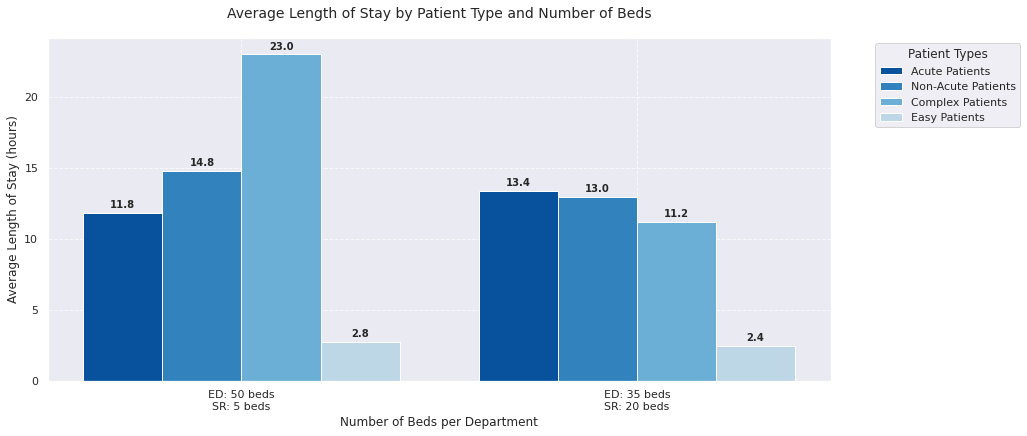

In [158]:
# Load results from saved files
results_folder = "Sensitivity Analysis"
results_dfs = {os.path.splitext(os.path.basename(path))[0]: pd.read_csv(os.path.join(results_folder, path))
               for path in os.listdir(results_folder)}

# Get bed combinations from the actual data and sort them
bed_combinations = []
for filename, df in results_dfs.items():
    ed_beds = df['numBedsED'].iloc[0]  # Get the ED beds from the data
    sr_beds = df['numBedsSR'].iloc[0]  # Get the SR beds from the data
    bed_combinations.append((ed_beds, sr_beds, filename))

# Sort by ED beds in descending order
bed_combinations_sorted = sorted(bed_combinations, key=lambda x: x[0], reverse=True)

beds_combinations = []
acute_wait_avg = []
notacute_wait_avg = []
complex_wait_avg = []
easy_wait_avg = []

# Process data in sorted order
for ed_beds, sr_beds, filename in bed_combinations_sorted:
    df = results_dfs[filename]
    beds_combinations.append(f"ED: {int(ed_beds)} beds\nSR: {int(sr_beds)} beds")
    acute_wait_avg.append(df['Avg_Acute_ED_Time'].mean())
    notacute_wait_avg.append(df['Avg_NotAcute_ED_Time'].mean())
    complex_wait_avg.append(df['Avg_Complex_ED_Time'].mean())
    easy_wait_avg.append(df['Avg_Easy_SR_Time'].mean())

x = np.arange(len(beds_combinations))
width = 0.2

# הגדרת צבעים
colors = ['#08519c', '#3182bd', '#6baed6', '#bdd7e7']

fig, ax = plt.subplots(figsize=(15, 7))
bars1 = ax.bar(x - 1.5 * width, acute_wait_avg, width, label='Acute Patients', color=colors[0])
bars2 = ax.bar(x - 0.5 * width, notacute_wait_avg, width, label='Non-Acute Patients', color=colors[1])
bars3 = ax.bar(x + 0.5 * width, complex_wait_avg, width, label='Complex Patients', color=colors[2])
bars4 = ax.bar(x + 1.5 * width, easy_wait_avg, width, label='Easy Patients', color=colors[3])

# הוספת ערכים מעל כל עמודה
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}',  # הפורמט להצגת הערך
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # מרחק מהעמודה
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

# הגדרת כותרות וצירים
ax.set_ylabel('Average Length of Stay (hours)', fontsize=12)
ax.set_xlabel('Number of Beds per Department', fontsize=12)
ax.set_title('Average Length of Stay by Patient Type and Number of Beds', fontsize=14, pad=20)

# עיצוב הצירים
ax.set_xticks(x)
ax.set_xticklabels(beds_combinations, rotation=0, ha="center")

# הוספת מקרא
ax.legend(title='Patient Types', bbox_to_anchor=(1.05, 1), loc='upper left')

# הוספת רשת
ax.grid(True, linestyle='--', alpha=0.7)

# התאמת המרווחים
plt.subplots_adjust(bottom=0.2, right=0.85)

# הצגת הגרף
plt.show()